## Import Library

In [97]:
import re
import unicodedata
import string
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory



## Load Dataset

In [98]:
df = pd.read_csv("./full_data.csv")

df = df.dropna(subset=["review"])
# df = df.head(2)
df["review"] = df["review"].astype(str)
df.head(5)

,username,review,rating,tahun,aplikasi
0,Bangbang Sugito,susah masuk kode otp ratusan x ga kekirim makin kesini makin parah,1,2025,bca
1,KECOA Bogor,"Udah capek capek lama isi pendaftaran habis itu disuruh nunggu video call, Pas video call semua data saya udah benar malah di bilang ada yang salah tanpa ngasih tau kesalahannya, dan langsung disuruh ke kantor cabang BCA 😂😂Kalo gitu ngapain dari awal daftar udahlah ribet,udah mau tahun 2026 daftar kek gini aja dibikin ribet, pantes rating 4.0, Tim BCA otaknya duit ya?gak mau ngelayanin pengguna lewat online?Otak ada gak?",1,2025,bca
2,Aryo Setho,SERING LAGGG. ERROR GAK BISA TRANSFER KE REKENING LAIN,1,2025,bca
3,Havid Karadin,Kenapa sekarang jadi sering trobel ya,2,2025,bca
4,muhammad surya,pertama enak buka setelah saya hapus lalu di installagi gak bisa buka hade,1,2025,bca


In [99]:
import pandas as pd

# Pastikan tidak ada NaN penting
df = df.dropna(subset=["review", "aplikasi", "rating"])

# Cek distribusi awal
print("Distribusi awal per aplikasi dan rating:")
print(df.groupby(["aplikasi", "rating"]).size())

# Tentukan target total per aplikasi
target_per_app = 2000

# Hitung jumlah rating unik
rating_count = df["rating"].nunique()

# Jumlah data per rating per aplikasi
n_per_rating = target_per_app // rating_count

# Sampling seimbang per aplikasi dan rating
df = (
    df.groupby(["aplikasi", "rating"], group_keys=False)
      .apply(lambda x: x.sample(
          n=min(n_per_rating, len(x)),
          random_state=42
      ))
      .reset_index(drop=True)
)

# Cek hasil
print("\nTotal data:", len(df))
print("\nDistribusi data per aplikasi:")
print(df["aplikasi"].value_counts())

print("\nDistribusi rating per aplikasi:")
print(df.groupby(["aplikasi", "rating"]).size())


Distribusi awal per aplikasi dan rating:
aplikasi  rating
bca       1         1691
          2          309
          3         2000
          4          256
          5         1744
brimo     1         1696
          2          304
          3         2000
          4          152
          5         2248
livin     1         1682
          2          318
          3         2000
          4          221
          5         1779
dtype: int64

Total data: 5160

Distribusi data per aplikasi:
aplikasi
bca      1765
livin    1739
brimo    1656
Name: count, dtype: int64

Distribusi rating per aplikasi:
aplikasi  rating
bca       1         400
          2         309
          3         400
          4         256
          5         400
brimo     1         400
          2         304
          3         400
          4         152
          5         400
livin     1         400
          2         318
          3         400
          4         221
          5         400
dtype: int64


C:\Users\acere\AppData\Local\Temp\ipykernel_15152\2157649229.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


# Preprocesssing

In [100]:
df["rating"].value_counts()

rating
1    1200
3    1200
5    1200
2     931
4     629
Name: count, dtype: int64

## Cleaning

In [101]:
def clean_text(text):
    text = text.lower()

    # ====== Hapus karakter non-ASCII ======
    text = text.encode("ascii", "ignore").decode()

    # ====== Hapus kata berulang ======
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # ====== Normalisasi unicode ======
    text = unicodedata.normalize("NFC", text)

    # ====== Hapus URL ======
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r'href\s*=\s*"[^\"]*"', " ", text)
    text = re.sub(r"href\s*=\s*'[^']*'", " ", text)
    text = re.sub(r"href\s*=\s*\S+", " ", text)

    # ====== Hapus HTML tag ======
    text = re.sub(r"<.*?>", " ", text)

    # ====== Hapus angka berdiri sendiri ======
    text = re.sub(r"\b\d+\b", " ", text)

    # ====== Hapus emoji ======
    emoji_pattern = re.compile("[" 
                               u"\U0001F600-\U0001F64F"
                               u"\U0001F300-\U0001F5FF"
                               u"\U0001F680-\U0001F6FF"
                               u"\U0001F1E0-\U0001F1FF"
                               u"\U00002500-\U00002BEF"
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(" ", text)
    # ====== Hapus punctuation (tanda baca) ======
    text = text.translate(str.maketrans("", "", string.punctuation))
    # ====== Hapus sisa simbol non alphabet ======
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # ====== Hapus spasi berlebih ======
    text = re.sub(r"\s+", " ", text).strip()
    return text

import json


## Normalize Slang, Typo

In [102]:
abbreviation = pd.read_csv(
    "./help-data/abbreviation.csv",
    delimiter=";",
    names=["abbreviation", "meaning"]
)

abbr_dict = dict(
    zip(
        abbreviation["abbreviation"].str.lower(),
        abbreviation["meaning"].str.lower()
    )
)

with open("./help-data/slang.json", "r", encoding="utf-8") as f:
    slang_dict = json.load(f)

slang_dict = {k.lower(): v.lower() for k, v in slang_dict.items()}

normalize_dict = {}
normalize_dict.update(abbr_dict)
# normalize_dict.update(slang_dict)


In [103]:
def normalize_text(text):
    tokens = text.split()
    return " ".join(
        normalize_dict.get(t, t) for t in tokens
    )


## Tokenisasi

In [104]:
def tokenize(text):
    return text.split()

## Stopwords Removal

In [105]:
import nltk
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acere\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [106]:
from nltk.corpus import stopwords

stopwords_nltk = set(stopwords.words("indonesian"))

important_words = {
    "tidak", "bisa", "sangat", "kurang", "gagal",
    "cepat", "mudah", "lama", "error", "lemot"
}

custom_stopwords = {
    "nya", "dong", "sih", "loh", "lah", "kok", "kan",
    "deh", "nih", "ya", "yah", "aja", "doang", "x", "dah", "yaa",
    "ini", "itu", "terus", "jadi", "buat", "kalo",
    "kalau", "pas", "biar", "kayak", "seperti", "apa",
    "kali", "lalu", "mulu", "ko", "makin", "gimana",
    "kak", "min", "admin", "gan"
}

stopwords = (stopwords_nltk | custom_stopwords) - important_words


def remove_stopwords(tokens):
    return [t for t in tokens if t not in stopwords]


## Stemming ( Ubah Kata Ke Bentuk dasar)

In [107]:
stemmer = StemmerFactory().create_stemmer()

def stemming(tokens):
    return [stemmer.stem(token) for token in tokens]

## Pipeline Preprocessing

In [108]:
def preprocess(text):
    text = clean_text(text)
    text = normalize_slang(text)

    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = stemming(tokens)

    return " ".join(tokens)

## Apply Preprocessing

In [109]:
df["clean_text"] = df["review"].apply(preprocess)
df.head()

,username,review,rating,tahun,aplikasi,clean_text
0,Lisna Wantin,sering elor,1,2025,bca,elor
1,Hans Kurniawan,"lemot, dikit-dikit lost connection. harus tunggu hijau lagi, lama",1,2025,bca,lama dikitdikit lost connection tunggu hijau lama
2,Abdurrachman Habib,gak bisa verifikasi muka ...,1,2025,bca,tidak bisa verifikasi muka
3,Rus Tio123,ATM ga jls tiba² kena aja verifikasi ulang lah registrasi ulang lah apa lah sampe ngga bisa TF di suruh bikin surat permohonan padahal ngga ada di apa²in tiba² begitu cape banget pake ATM BCA ni ga jelas,1,2025,bca,atm tidak jls kena verifikasi ulang registrasi ulang tidak bisa transfer suruh surat mohon tidak apain cape banget pakai atm bca tidak
4,shela zea (firman),apk ny skrng aneh ntah admin nya di pesan ga jawab² login pun. di persulit smpe2 sya pke hp 2 pun ga bisa masuk hdeh,1,2025,bca,aplikasi ny skrng aneh ntah pesan tidak login sulit smpe sya pakai handphone tidak bisa masuk hdeh


In [110]:

sample_df = df.head(5).copy()  

sample_df["cleaning"] = sample_df["review"].apply(clean_text)
sample_df["normalized"] = sample_df["review"].apply(lambda x: normalize_slang(clean_text(x)))
sample_df["tokenized"] = sample_df["review"].apply(lambda x: tokenize(normalize_slang(clean_text(x))))
sample_df["no_stopwords"] = sample_df["review"].apply(lambda x: remove_stopwords(tokenize(normalize_slang(clean_text(x)))))
sample_df["stemmed"] = sample_df["review"].apply(lambda x: stemming(remove_stopwords(tokenize(normalize_slang(clean_text(x))))))

pd.set_option("display.max_colwidth", None)
sample_df[["review","cleaning","normalized","tokenized","no_stopwords","stemmed","clean_text"]]

,review,cleaning,normalized,tokenized,no_stopwords,stemmed,clean_text
0,sering elor,sering elor,sering elor,"[sering, elor]",[elor],[elor],elor
1,"lemot, dikit-dikit lost connection. harus tunggu hijau lagi, lama",lemot dikitdikit lost connection harus tunggu hijau lagi lama,lama dikitdikit lost connection harus tunggu hijau lagi lama,"[lama, dikitdikit, lost, connection, harus, tunggu, hijau, lagi, lama]","[lama, dikitdikit, lost, connection, tunggu, hijau, lama]","[lama, dikitdikit, lost, connection, tunggu, hijau, lama]",lama dikitdikit lost connection tunggu hijau lama
2,gak bisa verifikasi muka ...,gak bisa verifikasi muka,tidak bisa verifikasi muka,"[tidak, bisa, verifikasi, muka]","[tidak, bisa, verifikasi, muka]","[tidak, bisa, verifikasi, muka]",tidak bisa verifikasi muka
3,ATM ga jls tiba² kena aja verifikasi ulang lah registrasi ulang lah apa lah sampe ngga bisa TF di suruh bikin surat permohonan padahal ngga ada di apa²in tiba² begitu cape banget pake ATM BCA ni ga jelas,atm ga jls tiba kena aja verifikasi ulang lah registrasi ulang lah apa lah sampe ngga bisa tf di suruh bikin surat permohonan padahal ngga ada di apain tiba begitu cape banget pake atm bca ni ga jelas,atm tidak jls tiba kena saja verifikasi ulang lah registrasi ulang lah apa lah sampai tidak bisa transfer di suruh membuat surat permohonan padahal tidak ada di apain tiba begitu cape banget pakai atm bca ini tidak jelas,"[atm, tidak, jls, tiba, kena, saja, verifikasi, ulang, lah, registrasi, ulang, lah, apa, lah, sampai, tidak, bisa, transfer, di, suruh, membuat, surat, permohonan, padahal, tidak, ada, di, apain, tiba, begitu, cape, banget, pakai, atm, bca, ini, tidak, jelas]","[atm, tidak, jls, kena, verifikasi, ulang, registrasi, ulang, tidak, bisa, transfer, suruh, surat, permohonan, tidak, apain, cape, banget, pakai, atm, bca, tidak]","[atm, tidak, jls, kena, verifikasi, ulang, registrasi, ulang, tidak, bisa, transfer, suruh, surat, mohon, tidak, apain, cape, banget, pakai, atm, bca, tidak]",atm tidak jls kena verifikasi ulang registrasi ulang tidak bisa transfer suruh surat mohon tidak apain cape banget pakai atm bca tidak
4,apk ny skrng aneh ntah admin nya di pesan ga jawab² login pun. di persulit smpe2 sya pke hp 2 pun ga bisa masuk hdeh,apk ny skrng aneh ntah admin nya di pesan ga jawab login pun di persulit smpe sya pke hp pun ga bisa masuk hdeh,aplikasi ny skrng aneh ntah admin nya di pesan tidak jawab login pun di persulit smpe sya pakai handphone pun tidak bisa masuk hdeh,"[aplikasi, ny, skrng, aneh, ntah, admin, nya, di, pesan, tidak, jawab, login, pun, di, persulit, smpe, sya, pakai, handphone, pun, tidak, bisa, masuk, hdeh]","[aplikasi, ny, skrng, aneh, ntah, pesan, tidak, login, persulit, smpe, sya, pakai, handphone, tidak, bisa, masuk, hdeh]","[aplikasi, ny, skrng, aneh, ntah, pesan, tidak, login, sulit, smpe, sya, pakai, handphone, tidak, bisa, masuk, hdeh]",aplikasi ny skrng aneh ntah pesan tidak login sulit smpe sya pakai handphone tidak bisa masuk hdeh


In [111]:
print(len(df))

5160


## Wordcloud 

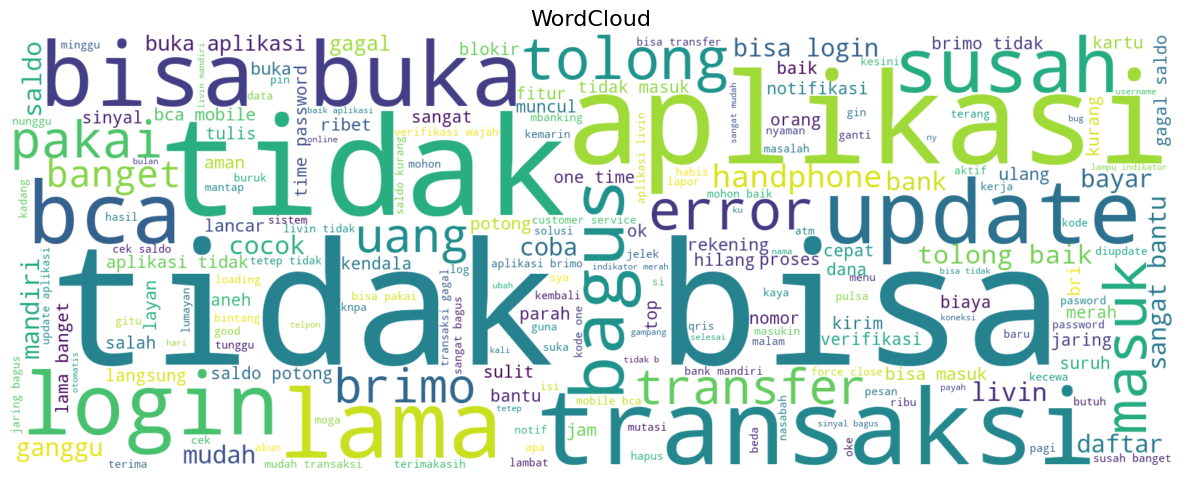

In [112]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df["clean_text"].tolist())

# Buat WordCloud
wc = WordCloud(
    width=1600,
    height=600,
    background_color="white",
).generate(all_text)

# Tampilkan
plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud", fontsize=16)
plt.show()

## Simpan Data

In [113]:
df.to_csv("./dataset_hasil_preprocessing/dataset.csv", index=False, encoding="utf-8")

In [114]:
df.columns

Index(['username', 'review', 'rating', 'tahun', 'aplikasi', 'clean_text'], dtype='object')